In [4]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Path to the raw dataset
DATA_DIR = Path(r"E:\Driver-Drowsiness\data\raw")

print("Dataset path:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

Dataset path: E:\Driver-Drowsiness\data\raw
Dataset exists: True


In [6]:
for split in ["train", "val", "test"]:
    split_dir = DATA_DIR / split
    
    print(f"\n{'='*50}")
    print(f"{split.upper()} DIRECTORY")
    print(f"{'='*50}")
    
    for class_name in ["active", "fatigue"]:
        class_dir = split_dir / class_name
        
        if class_dir.exists():
            print(f"{class_name}: {len(list(class_dir.glob('*.jpg')))} images")
        else:
            print(f"{class_name}: folder not found")


TRAIN DIRECTORY
active: 5862 images
fatigue: 3192 images

VAL DIRECTORY
active: 912 images
fatigue: 912 images

TEST DIRECTORY
active: 456 images
fatigue: 453 images


In [7]:
dataset_stats = []

for split in ["train", "val", "test"]:
    for class_name in ["active", "fatigue"]:
        
        class_dir = DATA_DIR / split / class_name
        count = len(list(class_dir.glob("*.jpg")))
        
        dataset_stats.append({
            "Split": split,
            "Class": class_name,
            "Count": count
        })

stats_df = pd.DataFrame(dataset_stats)

display(stats_df)

,Split,Class,Count
0,train,active,5862
1,train,fatigue,3192
2,val,active,912
3,val,fatigue,912
4,test,active,456
5,test,fatigue,453


In [8]:
total_images = stats_df["Count"].sum()

class_totals = stats_df.groupby("Class")["Count"].sum()

print("Total images:", total_images)

print("\nImages by class:")
display(class_totals.to_frame(name="Count"))

Total images: 11787

Images by class:


,Count
Class,
active,7230
fatigue,4557


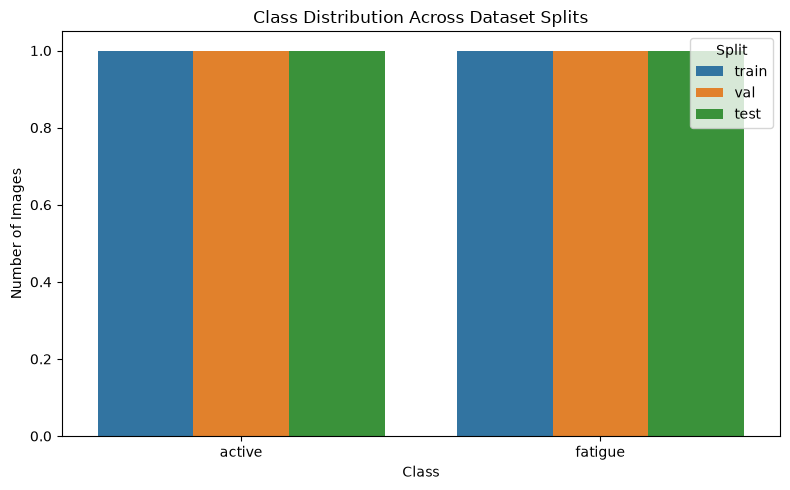

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=stats_df,
    x="Class",
    hue="Split"
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [10]:
class_percentages = (
    stats_df.groupby("Class")["Count"]
    .sum()
    .div(total_images)
    .mul(100)
)

print("Overall class distribution:")

for class_name, percentage in class_percentages.items():
    print(f"{class_name}: {percentage:.2f}%")

Overall class distribution:
active: 61.34%
fatigue: 38.66%


In [11]:
extensions = Counter()

for file in DATA_DIR.rglob("*"):
    if file.is_file():
        extensions[file.suffix.lower()] += 1

print("File extensions:")
for ext, count in extensions.items():
    print(f"{ext}: {count}")

File extensions:
.txt: 3
.jpg: 11787


In [13]:
image_sizes = Counter()
image_modes = Counter()
corrupt_images = []

all_images = list(DATA_DIR.rglob("*.jpg"))

for image_path in all_images:
    try:
        with Image.open(image_path) as img:
            image_sizes[img.size] += 1
            image_modes[img.mode] += 1
            
    except Exception:
        corrupt_images.append(image_path)

print("Most common image sizes:")
for size, count in image_sizes.most_common(10):
    print(f"{size}: {count}")

print("\nImage modes:")
print(image_modes)

print("\nCorrupt images:", len(corrupt_images))

Most common image sizes:
(1080, 1920): 4604
(1080, 720): 2688
(1920, 1080): 1598
(720, 1280): 1057
(640, 480): 860
(1280, 720): 574
(480, 853): 212
(896, 592): 194

Image modes:
Counter({'RGB': 11787})

Corrupt images: 0


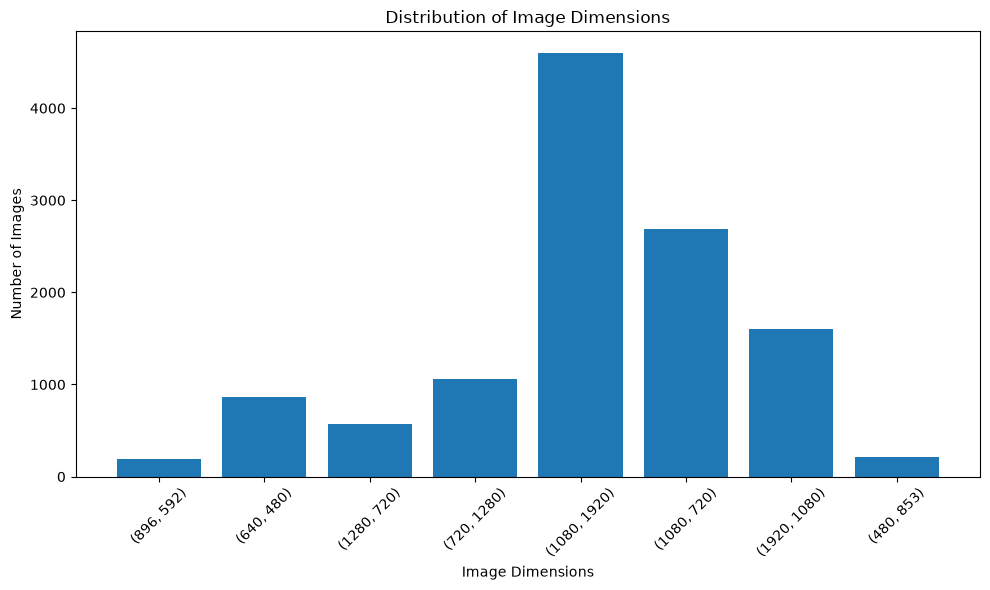

In [14]:
sizes = list(image_sizes.keys())
counts = list(image_sizes.values())

plt.figure(figsize=(10, 6))

plt.bar(
    [str(size) for size in sizes],
    counts
)

plt.title("Distribution of Image Dimensions")
plt.xlabel("Image Dimensions")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

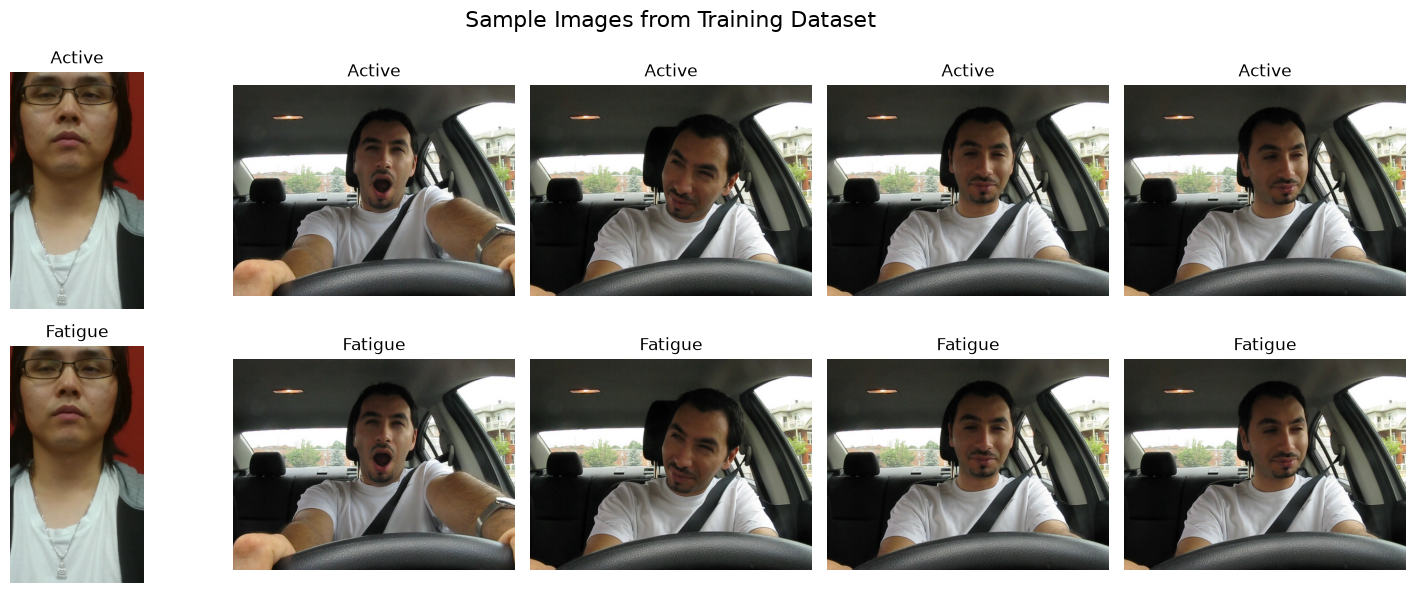

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, class_name in enumerate(["active", "fatigue"]):
    
    class_dir = DATA_DIR / "train" / class_name
    
    image_paths = sorted(class_dir.glob("*.jpg"))[:5]
    
    for col, image_path in enumerate(image_paths):
        
        img = Image.open(image_path)
        
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name.capitalize())
        axes[row, col].axis("off")

plt.suptitle("Sample Images from Training Dataset", fontsize=16)

plt.tight_layout()
plt.show()

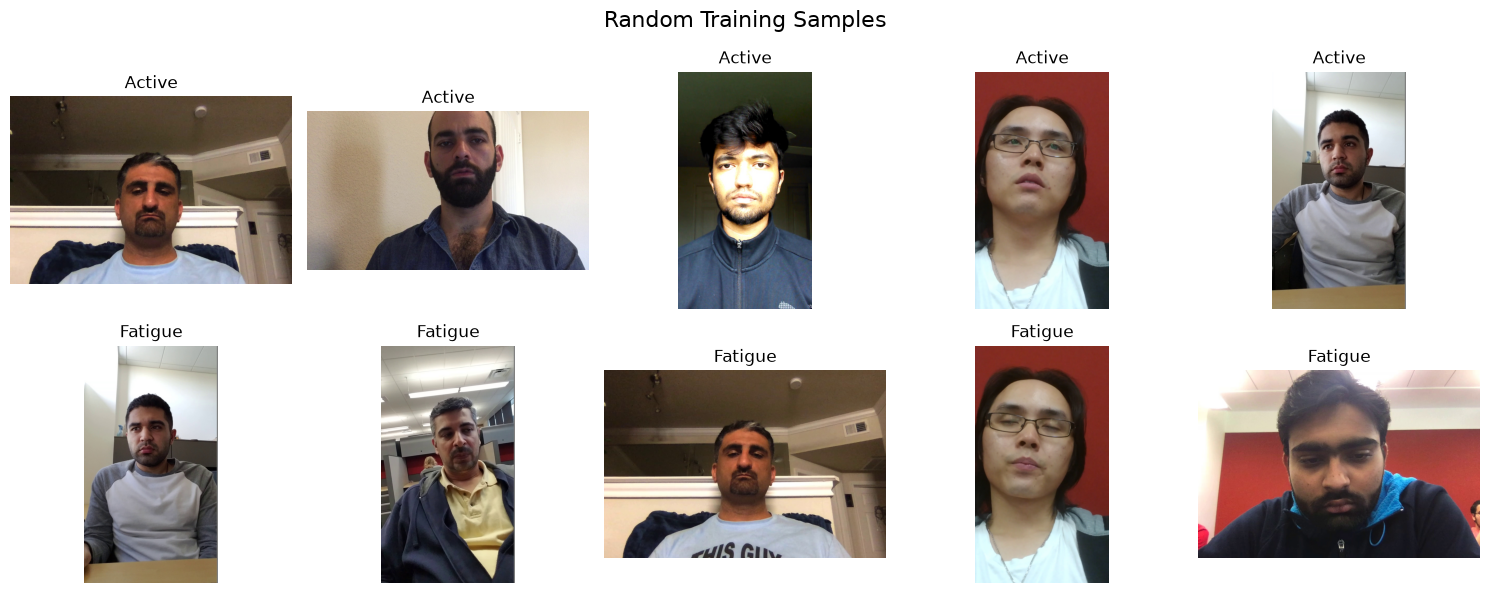

In [16]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, class_name in enumerate(["active", "fatigue"]):
    
    class_dir = DATA_DIR / "train" / class_name
    
    image_paths = list(class_dir.glob("*.jpg"))
    selected = random.sample(image_paths, 5)
    
    for col, image_path in enumerate(selected):
        
        img = Image.open(image_path)
        
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name.capitalize())
        axes[row, col].axis("off")

plt.suptitle("Random Training Samples", fontsize=16)

plt.tight_layout()
plt.show()

In [17]:
brightness_values = []

for image_path in all_images:
    
    try:
        with Image.open(image_path).convert("L") as img:
            image_array = np.array(img)
            brightness_values.append(image_array.mean())
            
    except Exception:
        pass

brightness_values = np.array(brightness_values)

print("Minimum brightness:", brightness_values.min())
print("Maximum brightness:", brightness_values.max())
print("Mean brightness:", brightness_values.mean())
print("Median brightness:", np.median(brightness_values))

Minimum brightness: 56.48903912282819
Maximum brightness: 207.52377684604247
Mean brightness: 114.27224601068606
Median brightness: 112.6414570473251


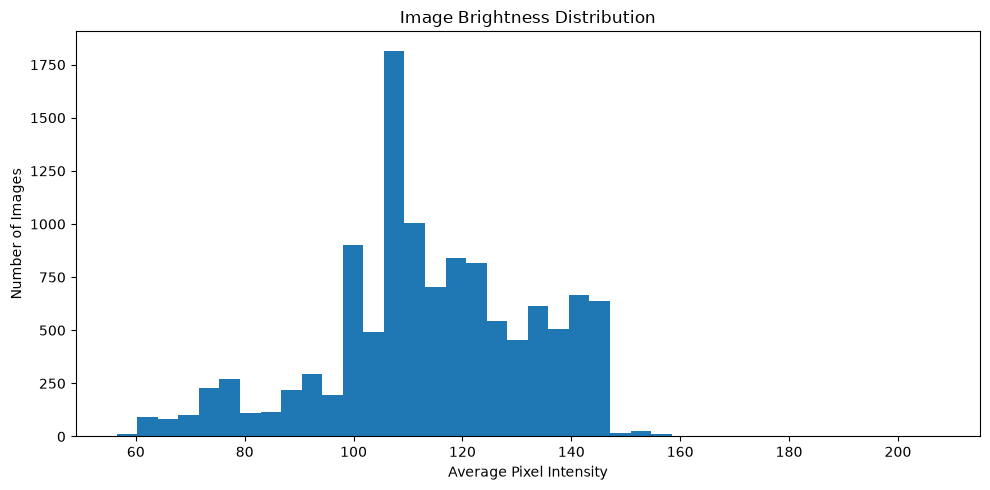

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    brightness_values,
    bins=40
)

plt.title("Image Brightness Distribution")
plt.xlabel("Average Pixel Intensity")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [19]:
import hashlib

hashes = {}

for image_path in all_images:
    
    try:
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        
        hashes.setdefault(file_hash, []).append(image_path)
        
    except Exception:
        pass

duplicate_groups = [
    paths for paths in hashes.values()
    if len(paths) > 1
]

print("Number of duplicate groups:", len(duplicate_groups))

duplicate_count = sum(len(paths) for paths in duplicate_groups)

print("Total duplicated files:", duplicate_count)

Number of duplicate groups: 2670
Total duplicated files: 5340


In [20]:
from collections import defaultdict
import hashlib

# Store: hash -> list of (split, class, file_path)
hash_records = defaultdict(list)

for split in ["train", "val", "test"]:
    for class_name in ["active", "fatigue"]:
        class_dir = DATA_DIR / split / class_name
        
        for image_path in class_dir.glob("*.jpg"):
            try:
                with open(image_path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                
                hash_records[file_hash].append(
                    (split, class_name, image_path)
                )
            
            except Exception:
                pass


# Find hashes appearing in more than one split
cross_split_duplicates = []

for file_hash, records in hash_records.items():
    splits = set(record[0] for record in records)
    
    if len(splits) > 1:
        cross_split_duplicates.append((file_hash, records))


print("Total unique image hashes:", len(hash_records))
print("Cross-split duplicate groups:", len(cross_split_duplicates))

Total unique image hashes: 9117
Cross-split duplicate groups: 0


In [21]:
conflicting_duplicates = []

for file_hash, records in hash_records.items():
    
    labels = set(record[1] for record in records)
    
    if len(labels) > 1:
        conflicting_duplicates.append((file_hash, records))


print("Duplicate groups with conflicting labels:",
      len(conflicting_duplicates))

Duplicate groups with conflicting labels: 2670


In [22]:
duplicate_location = Counter()

for file_hash, records in hash_records.items():
    
    if len(records) > 1:
        splits = sorted(set(record[0] for record in records))
        
        location = " + ".join(splits)
        duplicate_location[location] += 1

print("Duplicate distribution:")
for location, count in duplicate_location.items():
    print(f"{location}: {count}")

Duplicate distribution:
train: 2670


In [23]:
for split in ["train", "val", "test"]:
    txt_path = DATA_DIR / f"{split}.txt"
    
    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f if line.strip()]
    
    txt_paths = set(line.split()[0].replace("\\", "/") for line in lines)
    
    folder_paths = set(
        str(p.relative_to(DATA_DIR)).replace("\\", "/")
        for p in (DATA_DIR / split).rglob("*.jpg")
    )
    
    print(f"\n{split.upper()}")
    print("TXT entries:", len(txt_paths))
    print("Folder images:", len(folder_paths))
    print("In TXT but not folder:", len(txt_paths - folder_paths))
    print("In folder but not TXT:", len(folder_paths - txt_paths))


TRAIN
TXT entries: 6384
Folder images: 9054
In TXT but not folder: 0
In folder but not TXT: 2670

VAL
TXT entries: 1715
Folder images: 1824
In TXT but not folder: 0
In folder but not TXT: 109

TEST
TXT entries: 909
Folder images: 909
In TXT but not folder: 0
In folder but not TXT: 0


In [24]:
from collections import defaultdict
import hashlib

def get_txt_records(split):
    txt_path = DATA_DIR / f"{split}.txt"

    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f if line.strip()]

    records = []

    for line in lines:
        parts = line.split()

        image_rel_path = parts[0].replace("\\", "/")
        label = parts[-1]

        image_path = DATA_DIR / image_rel_path

        records.append((image_path, label))

    return records


for split in ["train", "val", "test"]:
    records = get_txt_records(split)

    hash_map = defaultdict(list)

    for image_path, label in records:

        if not image_path.exists():
            continue

        with open(image_path, "rb") as f:
            image_hash = hashlib.md5(f.read()).hexdigest()

        hash_map[image_hash].append((image_path, label))

    duplicate_groups = [
        items for items in hash_map.values()
        if len(items) > 1
    ]

    conflicting_groups = [
        items for items in duplicate_groups
        if len(set(label for _, label in items)) > 1
    ]

    print(f"\n{split.upper()}")
    print("TXT samples:", len(records))
    print("Unique hashes:", len(hash_map))
    print("Duplicate groups:", len(duplicate_groups))
    print("Conflicting-label groups:", len(conflicting_groups))


TRAIN
TXT samples: 6384
Unique hashes: 6384
Duplicate groups: 0
Conflicting-label groups: 0

VAL
TXT samples: 1715
Unique hashes: 1715
Duplicate groups: 0
Conflicting-label groups: 0

TEST
TXT samples: 909
Unique hashes: 909
Duplicate groups: 0
Conflicting-label groups: 0


In [25]:
for split in ["train", "val", "test"]:
    records = get_txt_records(split)

    label_counts = Counter(label for _, label in records)

    print(f"\n{split.upper()}")
    print("Active:", label_counts.get("0", 0))
    print("Fatigue:", label_counts.get("1", 0))


TRAIN
Active: 3192
Fatigue: 3192

VAL
Active: 912
Fatigue: 803

TEST
Active: 456
Fatigue: 453


In [26]:
records = []

for split in ["train", "val", "test"]:
    split_records = get_txt_records(split)
    
    for image_path, label in split_records:
        records.append({
            "split": split,
            "label": int(label),
            "class": "active" if label == "0" else "fatigue",
            "path": str(image_path)
        })

df = pd.DataFrame(records)

print("Total samples:", len(df))
display(df.head())

Total samples: 9008


,split,label,class,path
0,train,0,active,E:\Driver-Drowsiness\data\raw\train\active\img...
1,train,0,active,E:\Driver-Drowsiness\data\raw\train\active\img...
2,train,0,active,E:\Driver-Drowsiness\data\raw\train\active\img...
3,train,0,active,E:\Driver-Drowsiness\data\raw\train\active\img...
4,train,0,active,E:\Driver-Drowsiness\data\raw\train\active\ima...


In [27]:
summary = (
    df.groupby(["split", "class"])
      .size()
      .unstack(fill_value=0)
)

summary["Total"] = summary.sum(axis=1)

display(summary)

class,active,fatigue,Total
split,,,
test,456,453,909
train,3192,3192,6384
val,912,803,1715


In [28]:
overall_class_counts = df["class"].value_counts()

overall_percentages = (
    overall_class_counts / len(df) * 100
)

print("Overall class distribution:\n")

for class_name in ["active", "fatigue"]:
    count = overall_class_counts[class_name]
    percentage = overall_percentages[class_name]
    
    print(f"{class_name.capitalize()}: {count} ({percentage:.2f}%)")

Overall class distribution:

Active: 4560 (50.62%)
Fatigue: 4448 (49.38%)


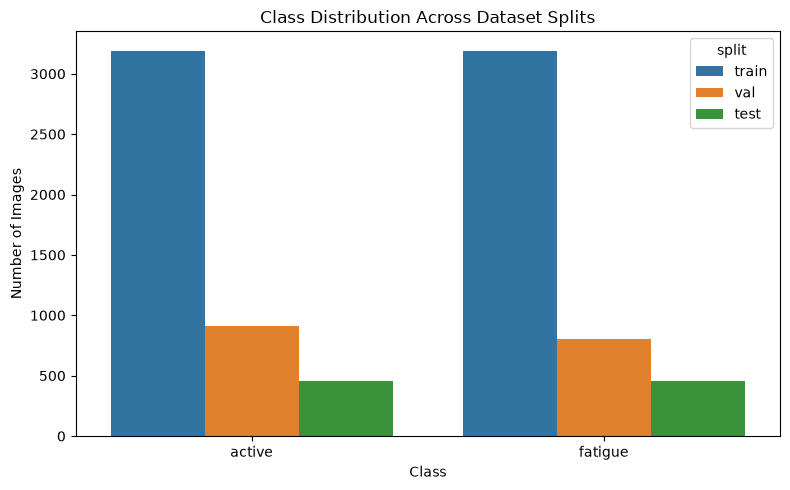

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="class",
    hue="split"
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [30]:
class_brightness = []

for _, row in df.iterrows():
    
    try:
        with Image.open(row["path"]).convert("L") as img:
            arr = np.array(img)
            
        class_brightness.append({
            "class": row["class"],
            "brightness": arr.mean()
        })
        
    except Exception:
        pass

brightness_df = pd.DataFrame(class_brightness)

display(
    brightness_df.groupby("class")["brightness"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

,count,mean,median,std,min,max
class,,,,,,
active,4560,116.812179,116.622548,15.725431,56.489039,207.523777
fatigue,4448,112.991206,111.165831,20.313634,59.393371,169.504068


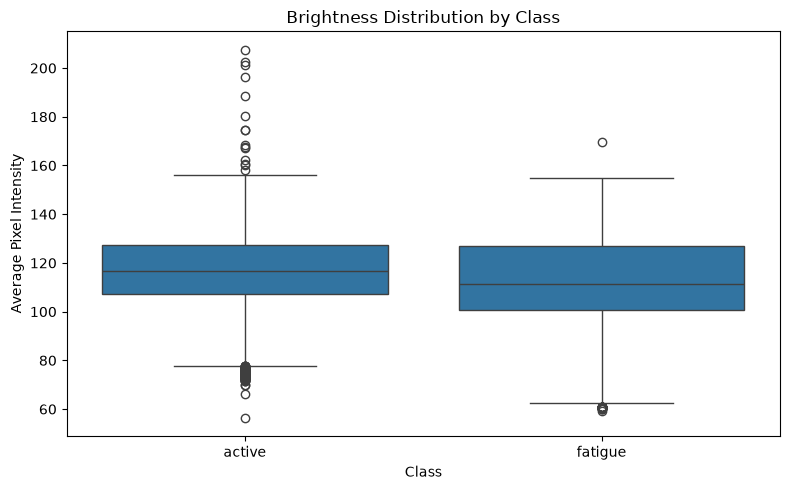

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=brightness_df,
    x="class",
    y="brightness"
)

plt.title("Brightness Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Average Pixel Intensity")

plt.tight_layout()
plt.show()

In [32]:
import cv2

sharpness_records = []

for _, row in df.sample(
    min(1000, len(df)),
    random_state=42
).iterrows():

    try:
        image = cv2.imread(row["path"])
        
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        sharpness = cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()
        
        sharpness_records.append({
            "class": row["class"],
            "sharpness": sharpness
        })
        
    except Exception:
        pass

sharpness_df = pd.DataFrame(sharpness_records)

display(
    sharpness_df.groupby("class")["sharpness"]
    .agg(["mean", "median", "std", "min", "max"])
)

,mean,median,std,min,max
class,,,,,
active,121.722787,53.874331,200.781088,3.870326,1981.975957
fatigue,95.686309,47.893365,169.834324,3.580693,2118.038389


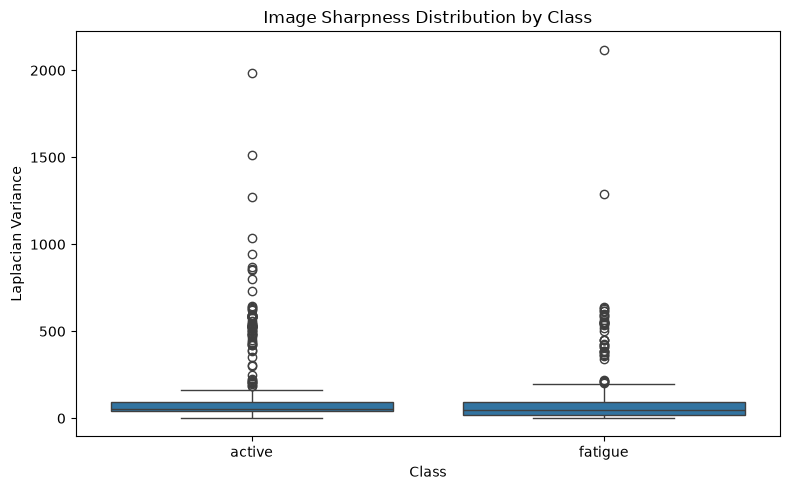

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=sharpness_df,
    x="class",
    y="sharpness"
)

plt.title("Image Sharpness Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Laplacian Variance")

plt.tight_layout()
plt.show()

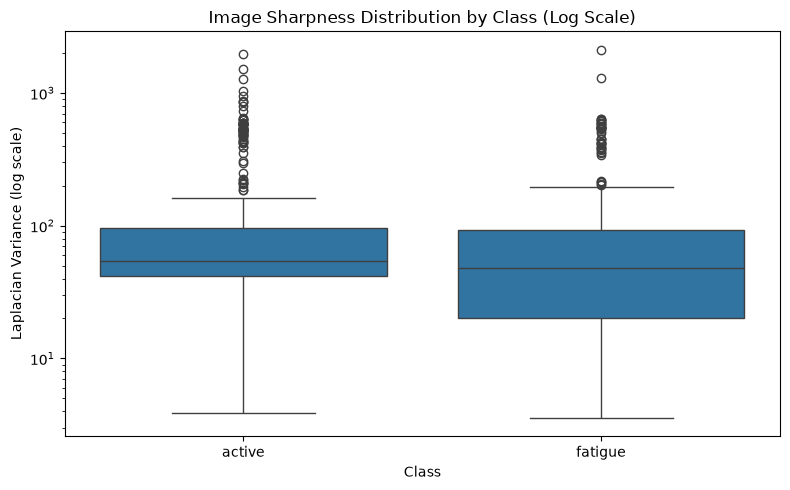

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=sharpness_df,
    x="class",
    y="sharpness"
)

plt.yscale("log")

plt.title("Image Sharpness Distribution by Class (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Laplacian Variance (log scale)")

plt.tight_layout()
plt.show()

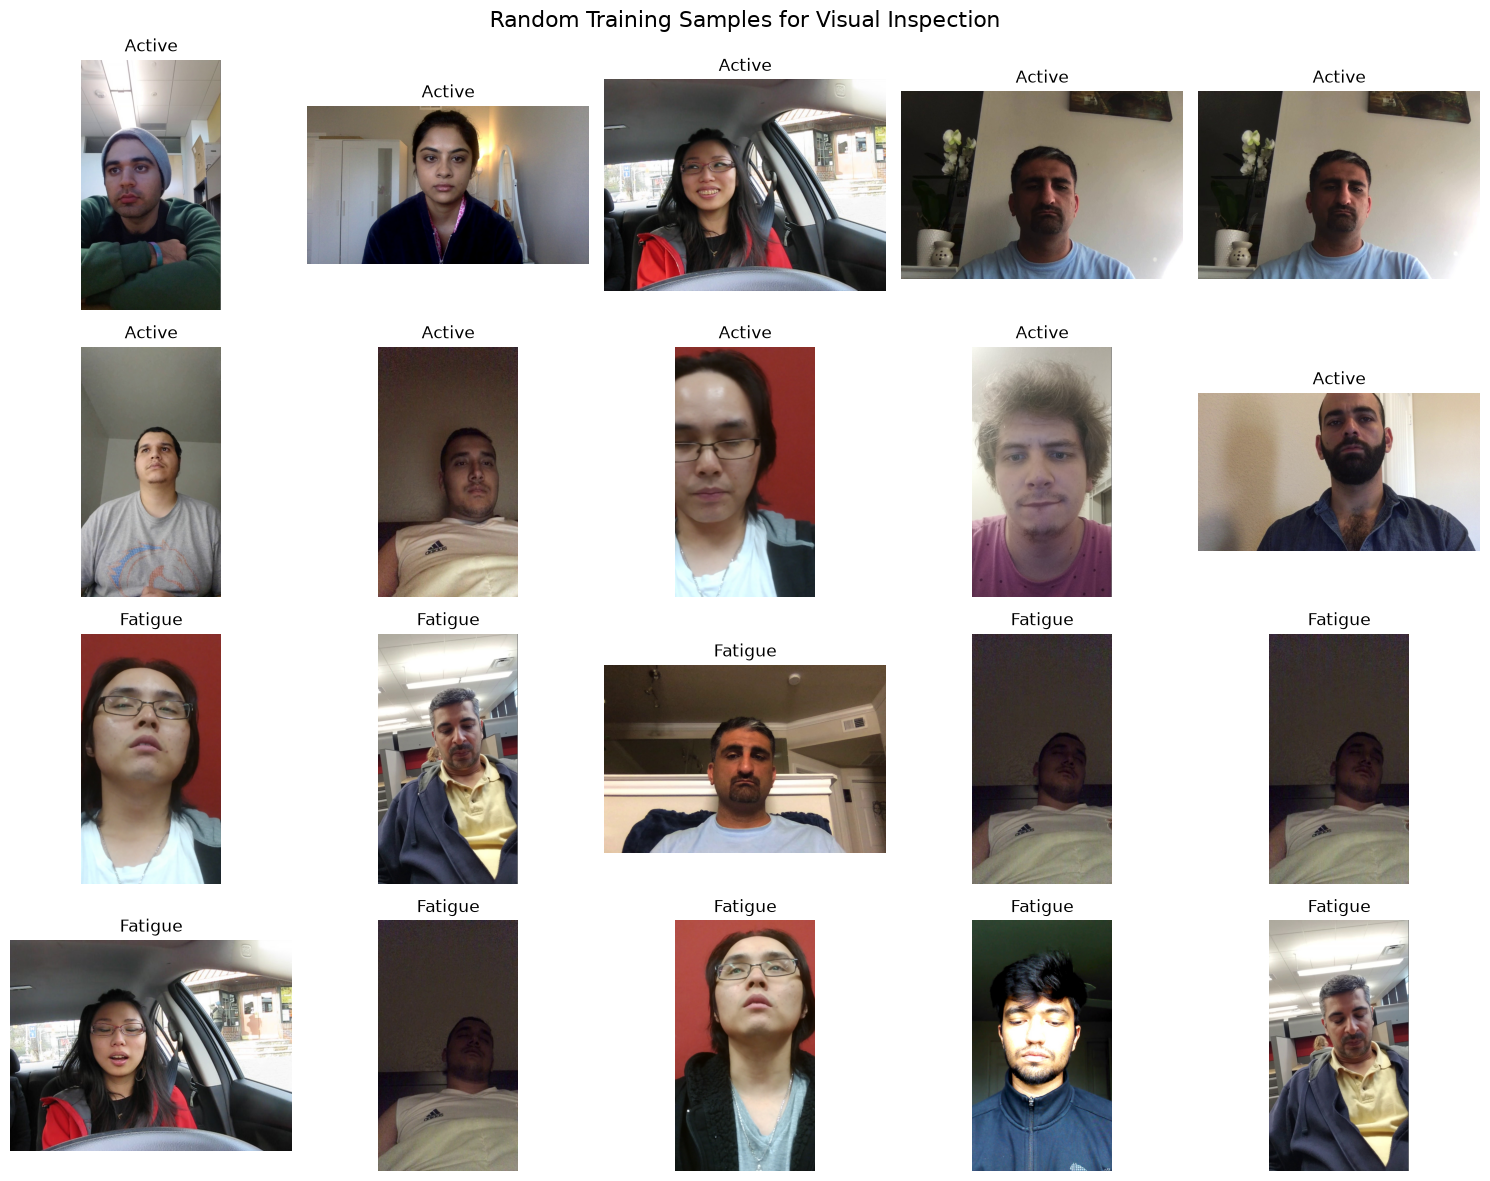

In [35]:
import random

random.seed(42)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row, class_name in enumerate(["active", "fatigue"]):
    
    class_paths = list(
        (DATA_DIR / "train" / class_name).glob("*.jpg")
    )
    
    selected_paths = random.sample(class_paths, 10)
    
    for i, image_path in enumerate(selected_paths):
        
        r = row * 2 + (i // 5)
        c = i % 5
        
        image = Image.open(image_path)
        
        axes[r, c].imshow(image)
        axes[r, c].set_title(class_name.capitalize())
        axes[r, c].axis("off")

plt.suptitle(
    "Random Training Samples for Visual Inspection",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [36]:
aspect_ratios = []

for image_path in all_images:
    
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            aspect_ratios.append(width / height)
            
    except Exception:
        pass

aspect_ratios = np.array(aspect_ratios)

print("Minimum aspect ratio:", aspect_ratios.min())
print("Maximum aspect ratio:", aspect_ratios.max())
print("Mean aspect ratio:", aspect_ratios.mean())
print("Median aspect ratio:", np.median(aspect_ratios))

Minimum aspect ratio: 0.5625
Maximum aspect ratio: 1.7777777777777777
Mean aspect ratio: 1.0721329194753617
Median aspect ratio: 1.3333333333333333


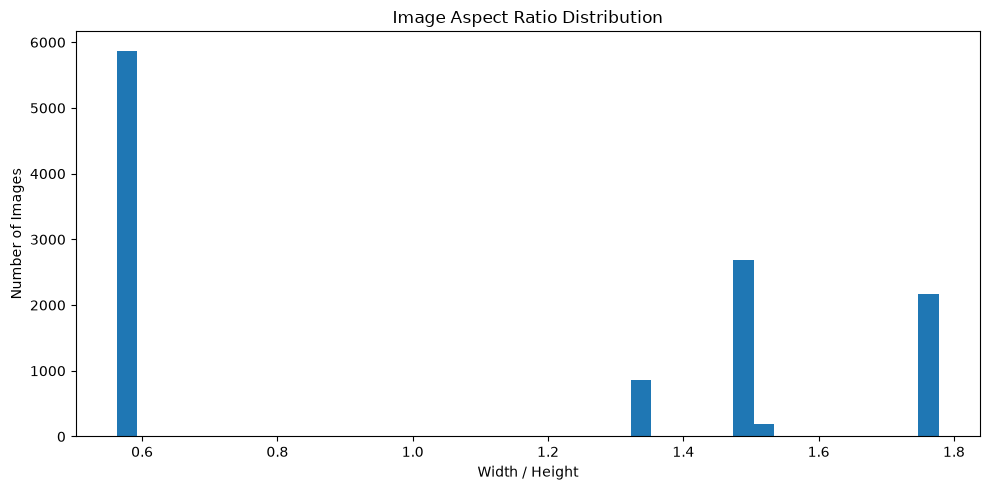

In [37]:
plt.figure(figsize=(10, 5))

plt.hist(
    aspect_ratios,
    bins=40
)

plt.title("Image Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [38]:
final_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test", "Total"],
    "Images": [
        len(df[df["split"] == "train"]),
        len(df[df["split"] == "val"]),
        len(df[df["split"] == "test"]),
        len(df)
    ]
})

display(final_summary)

,Split,Images
0,Train,6384
1,Validation,1715
2,Test,909
3,Total,9008


In [39]:
image_sizes_manifest = Counter()
image_modes_manifest = Counter()
corrupt_images_manifest = []

manifest_images = [Path(p) for p in df["path"]]

for image_path in manifest_images:
    try:
        with Image.open(image_path) as img:
            image_sizes_manifest[img.size] += 1
            image_modes_manifest[img.mode] += 1

    except Exception:
        corrupt_images_manifest.append(image_path)

print("Most common image sizes:")
for size, count in image_sizes_manifest.most_common(10):
    print(f"{size}: {count}")

print("\nImage modes:")
print(image_modes_manifest)

print("\nCorrupt images:", len(corrupt_images_manifest))

Most common image sizes:
(1080, 1920): 3669
(1080, 720): 1789
(1920, 1080): 1184
(720, 1280): 751
(640, 480): 692
(1280, 720): 554
(480, 853): 186
(896, 592): 183

Image modes:
Counter({'RGB': 9008})

Corrupt images: 0


In [40]:
manifest_aspect_ratios = []

for image_path in manifest_images:

    try:
        with Image.open(image_path) as img:
            width, height = img.size
            manifest_aspect_ratios.append(width / height)

    except Exception:
        pass

manifest_aspect_ratios = np.array(manifest_aspect_ratios)

print("Minimum aspect ratio:", manifest_aspect_ratios.min())
print("Maximum aspect ratio:", manifest_aspect_ratios.max())
print("Mean aspect ratio:", manifest_aspect_ratios.mean())
print("Median aspect ratio:", np.median(manifest_aspect_ratios))

Minimum aspect ratio: 0.5625
Maximum aspect ratio: 1.7777777777777777
Mean aspect ratio: 1.0617044074743327
Median aspect ratio: 0.5627198124267292


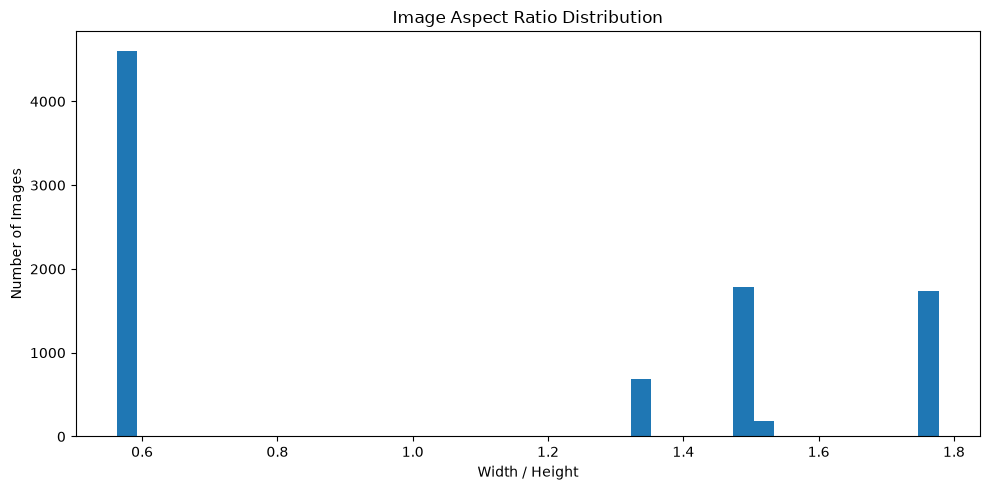

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(manifest_aspect_ratios, bins=40)

plt.title("Image Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

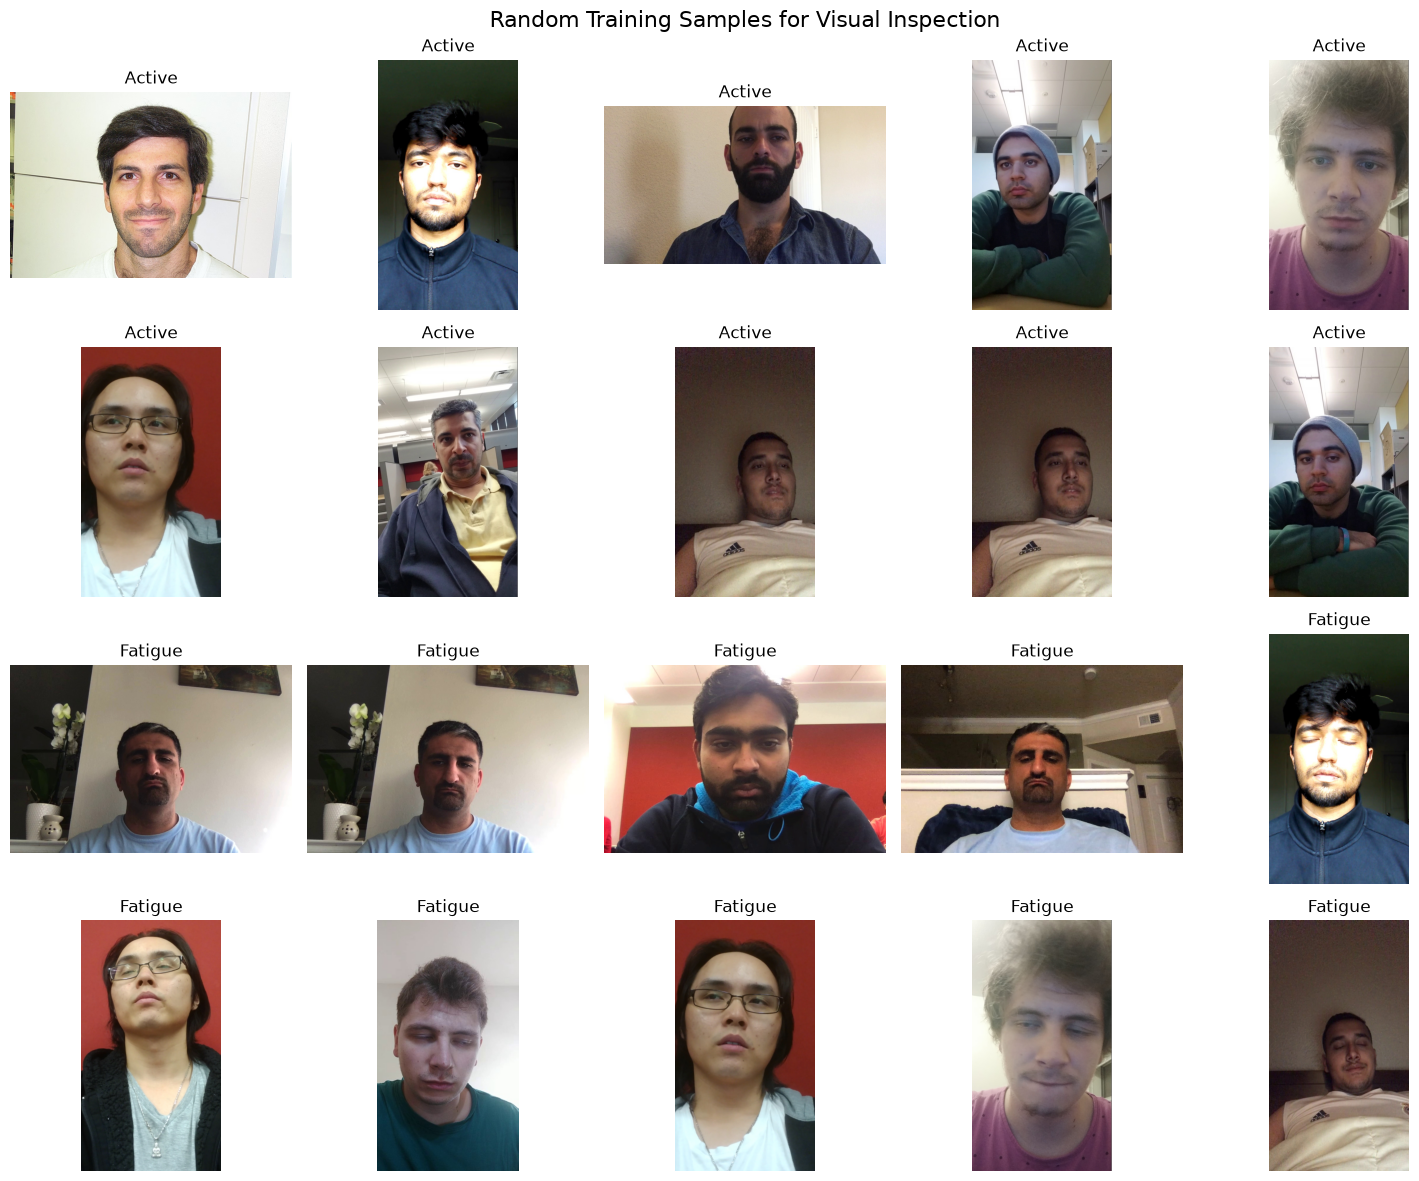

In [42]:
import random

random.seed(42)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row, class_name in enumerate(["active", "fatigue"]):

    class_paths = [
        Path(p) for p in df[
            (df["split"] == "train") &
            (df["class"] == class_name)
        ]["path"]
    ]

    selected_paths = random.sample(class_paths, 10)

    for i, image_path in enumerate(selected_paths):

        r = row * 2 + (i // 5)
        c = i % 5

        image = Image.open(image_path)

        axes[r, c].imshow(image)
        axes[r, c].set_title(class_name.capitalize())
        axes[r, c].axis("off")

plt.suptitle(
    "Random Training Samples for Visual Inspection",
    fontsize=16
)

plt.tight_layout()
plt.show()

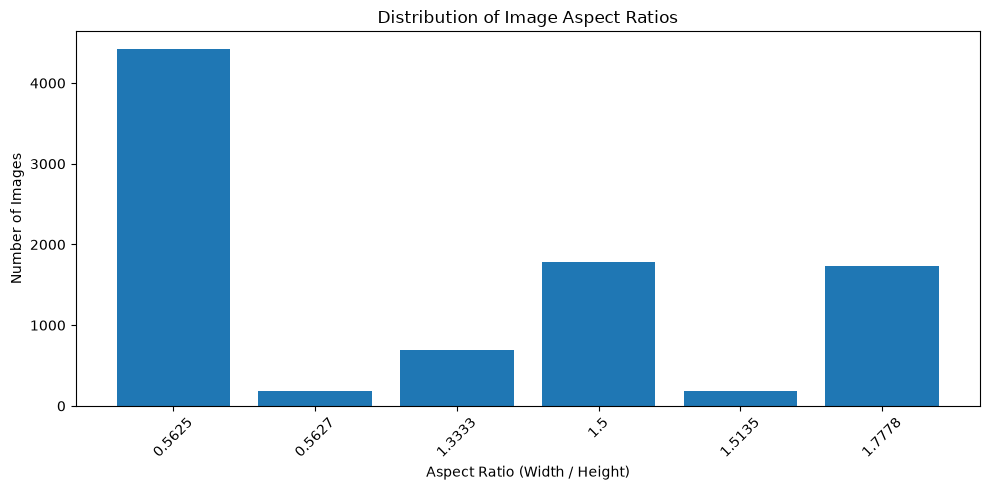

In [43]:
# Count the exact aspect ratios
aspect_ratio_counts = Counter(
    round(r, 4) for r in manifest_aspect_ratios
)

# Sort by aspect ratio
sorted_ratios = sorted(aspect_ratio_counts.items())

plt.figure(figsize=(10, 5))

plt.bar(
    [str(ratio) for ratio, _ in sorted_ratios],
    [count for _, count in sorted_ratios]
)

plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()